# Conditional Diffusion for Turbine Operation <sup>🔥 gas turbine</sup>

**The task on your desk.** Your historian has holes in it. Comms drop, analysers go offline for
maintenance, a card fails and takes a week of readings with it. Before you can trend anything,
fit a soft sensor, or hand the data to reliability, somebody has to decide what goes in the gaps.

Today you build a generative model of the unit, use it to fill real holes in real data, and —
the part that decides whether it was worth doing — **check it against the two methods you would
otherwise use**: linear interpolation and a cross-channel regression.

You will also get an answer to a question you can actually use on shift: **how long does a gap
have to be before interpolation stops being good enough?**

| | |
|---|---|
| **Data** | one gas turbine, 36,733 hourly records, 2011–2015, 11 tags |
| **Model** | conditional DDPM (1D U-Net) with classifier-free guidance |
| **Job** | fill historian gaps, scored against withheld truth on years the model never saw |
| **Baselines** | linear interpolation, hold-last, previous-day profile, cross-channel OLS |

> **Runtime.** ~20 min end to end (measured: 1,192 s on an Apple M-series GPU). Roughly half is
> the 2,240 training steps and half is the gap-filling sweep, which fills every gap five times.
>
> **Data.** UCI *Gas Turbine CO and NOx Emission Data Set* (Kaya, Tüfekci & Uzun), **CC BY 4.0**.

## Setup

In [1]:
#@title imports
import math, io, zipfile, urllib.request, copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.seterr(all="ignore")          # Apple/BLAS builds raise spurious matmul FPE flags
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.8.0


In [2]:
#@title download the UCI gas turbine dataset
URL  = "https://archive.ics.uci.edu/static/public/551/gas+turbine+co+and+nox+emission+data+set.zip"
root = Path("gt"); root.mkdir(exist_ok=True)
zp   = root / "gt.zip"
if not zp.exists():
    urllib.request.urlretrieve(URL, zp)
with zipfile.ZipFile(zp) as z:
    z.extractall(root)

TAGS = ["AT","AP","AH","AFDP","GTEP","TIT","TAT","TEY","CDP","CO","NOX"]
df = pd.concat([pd.read_csv(root / f"gt_{y}.csv").assign(year=y) for y in range(2011, 2016)],
               ignore_index=True)
print(f"{len(df):,} hourly records | {df.year.min()}-{df.year.max()} | {len(TAGS)} tags")
assert df[TAGS].isna().sum().sum() == 0, "unexpected NaNs"

36,733 hourly records | 2011-2015 | 11 tags


## The machine

Every tag here is one a utilities engineer already trends on a DCS.

| Tag | Units | What it is |
|---|---|---|
| `AT`, `AP`, `AH` | °C, mbar, % | ambient temperature, pressure, relative humidity |
| `AFDP` | mbar | air filter differential pressure |
| `GTEP` | mbar | exhaust pressure |
| `TIT`, `TAT` | °C | turbine inlet / after temperature |
| `TEY` | MWh | energy yield — the load |
| `CDP` | mbar | compressor discharge pressure |
| `CO`, `NOX` | mg/m³ | stack emissions |

## Know your data

Four questions before any modelling. Each one changes the lab design, and the fourth one is the
reason the first version of this notebook was wrong.

AT      0.993
AP      0.997
AH      0.958
AFDP    0.921
GTEP    0.856
TIT     0.826
TAT     0.841
TEY     0.853
CDP     0.857
CO      0.655
NOX     0.896

weakest channel: CO at 0.655


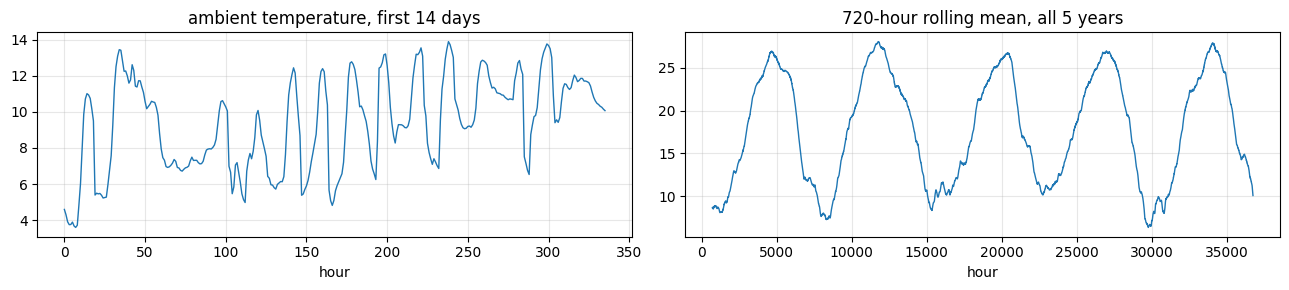

In [3]:
#@title 1. is this a real time series, or has it been shuffled?
acf = pd.Series({c: df[c].autocorr(1) for c in TAGS}, name="lag-1 autocorr")
print(acf.round(3).to_string())
print(f"\nweakest channel: {acf.idxmin()} at {acf.min():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(df["AT"].values[:336], lw=1); ax[0].set_title("ambient temperature, first 14 days")
ax[1].plot(df["AT"].rolling(720).mean().values, lw=1); ax[1].set_title("720-hour rolling mean, all 5 years")
for a in ax: a.grid(alpha=0.3); a.set_xlabel("hour")
plt.tight_layout(); plt.show()

In [4]:
#@title 2. how much of the calendar is missing?
rows = []
for y in range(2011, 2016):
    hours = 8784 if y % 4 == 0 else 8760
    n = int((df.year == y).sum())
    rows.append({"rows": n, "calendar hours": hours, "missing %": 100 * (1 - n / hours)})
print(pd.DataFrame(rows, index=range(2011, 2016)).round(1).to_string())

      rows  calendar hours  missing %
2011  7411            8760       15.4
2012  7628            8784       13.2
2013  7152            8760       18.4
2014  7158            8760       18.3
2015  7384            8760       15.7


In [5]:
#@title 3. where are the hard physical limits?
lim = pd.DataFrame({
    "min":  [df[c].min()  for c in TAGS],
    "max":  [df[c].max()  for c in TAGS],
    "most common value": [df[c].value_counts().index[0] for c in TAGS],
    "share of hours %":  [100 * df[c].value_counts(normalize=True).iloc[0] for c in TAGS],
}, index=TAGS)
print(lim.round(2).to_string())
print(f"\nTIT within 1 degC of its 1100 ceiling: {100*(df.TIT >= 1099).mean():.2f}% of hours")
print(f"TAT within 1 degC of its 550 setpoint: {100*((df.TAT >= 549) & (df.TAT <= 551)).mean():.2f}% of hours")

          min      max  most common value  share of hours %
AT      -6.23    37.10              18.52              0.02
AP     985.85  1036.60            1012.10              0.81
AH      24.08   100.20             100.14              0.13
AFDP     2.09     7.61               4.01              0.02
GTEP    17.70    40.72              24.31              0.05
TIT   1000.80  1100.90            1100.00              7.45
TAT    511.04   550.61             550.01              1.79
TEY    100.02   179.50             133.78              0.50
CDP      9.85    15.16              11.89              0.15
CO       0.00    44.10               0.11              0.06
NOX     25.90   119.91              60.38              0.28

TIT within 1 degC of its 1100 ceiling: 23.95% of hours
TAT within 1 degC of its 550 setpoint: 67.42% of hours


      skew  kurtosis  zero sits at z =
AT   -0.04     -0.83             -2.38
AP    0.19      0.44           -156.74
AH   -0.63     -0.27             -5.38
AFDP  0.38      0.22             -5.07
GTEP  0.33     -0.65             -6.09
TIT  -0.89     -0.05            -61.67
TAT  -1.76      2.02            -79.82
TEY   0.12     -0.50             -8.55
CDP   0.24     -0.63            -11.08
CO    4.84     49.07             -1.05
NOX   1.03      2.04             -5.59

CO        skew  4.84  kurtosis  49.07  floor at z = -1.05
log1p(CO) skew  0.83  kurtosis   1.18  floor at z = -2.25

Gaussian fitted to CO       -> 14.57% negative, worst   -8.61 mg/m3
Gaussian fitted to log1p(CO) ->  1.19% negative, worst   -0.63 mg/m3   <- expm1 cannot go below -1


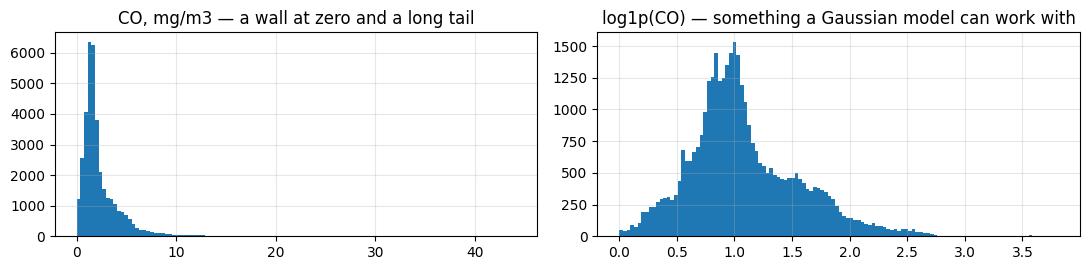

In [6]:
#@title 4. which tags are not remotely Gaussian?
from scipy import stats
shape = pd.DataFrame({
    "skew":     [stats.skew(df[c])     for c in TAGS],
    "kurtosis": [stats.kurtosis(df[c]) for c in TAGS],
    "zero sits at z =": [(0 - df[c].mean()) / df[c].std() for c in TAGS],
}, index=TAGS)
print(shape.round(2).to_string())

co_raw, co_log = df.CO.values, np.log1p(df.CO.values)
print(f"\nCO        skew {stats.skew(co_raw):5.2f}  kurtosis {stats.kurtosis(co_raw):6.2f}"
      f"  floor at z = {(0-co_raw.mean())/co_raw.std():+.2f}")
print(f"log1p(CO) skew {stats.skew(co_log):5.2f}  kurtosis {stats.kurtosis(co_log):6.2f}"
      f"  floor at z = {(0-co_log.mean())/co_log.std():+.2f}")

# what does that cost you? fit a Gaussian to each and draw from it.
rng = np.random.RandomState(0)
draw_raw = rng.randn(200_000)*co_raw.std() + co_raw.mean()
draw_log = np.expm1(rng.randn(200_000)*co_log.std() + co_log.mean())
print(f"\nGaussian fitted to CO       -> {100*(draw_raw<0).mean():5.2f}% negative, worst {draw_raw.min():7.2f} mg/m3")
print(f"Gaussian fitted to log1p(CO) -> {100*(draw_log<0).mean():5.2f}% negative, worst {draw_log.min():7.2f} mg/m3"
      "   <- expm1 cannot go below -1")

fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].hist(co_raw, bins=120); ax[0].set_title("CO, mg/m3 — a wall at zero and a long tail")
ax[1].hist(co_log, bins=120); ax[1].set_title("log1p(CO) — something a Gaussian model can work with")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

These four cells decide the whole lab.

- **It is a real, chronologically ordered series** — every tag strongly autocorrelated at lag 1,
  with a visible diurnal cycle. Windowed generation is meaningful.
- **13–18% of every year is missing**, and with no timestamp column you cannot locate the holes.
  That is the problem this lab solves, and it is what a historian actually looks like.
- **Two tags are under closed-loop control.** `TIT` is held below a 1100 °C limiter (24% of hours
  within 1 °C of it) and `TAT` at a 550 °C setpoint (two-thirds of hours). Those pile-ups are the
  controller's signature — a model either reproduces them or it does not understand the unit.
- **`CO` is not a Gaussian variable.** Skew 4.9, kurtosis 53, and a hard floor at zero sitting only
  **one standard deviation below the mean**. A diffusion model puts Gaussian noise on an unbounded
  tensor, so hand it raw `CO` and it *will* generate negative concentrations however well trained.
  `log1p` moves the floor to −2σ and drops the skew to 0.9. **We model `log1p(CO)` and invert on
  the way out.**

## Windows, split, and the conditioning label

- **Window = 168 rows**, our "week".
- **Split by year**: train on 2011–2013, hold out 2014–2015. Windows overlap, so splitting at
  random would leak; splitting by year is the only honest option.
- **Standardise on training years only**, with `log1p` applied to `CO` first.
- **Label = which third of the ambient-temperature range the week sits in** — cold, mild, hot.
  Terciles taken from the training windows. This is what we will condition on.

In [7]:
#@title the transform, the windows and the labels
WINDOW    = 168      # hours in our "week"
STRIDE_TR = 3
STRIDE_TE = 6
N_CLASSES = 3
CLASS_NAMES = ["cold", "mild", "hot"]
CO_IDX = TAGS.index("CO")

train_df, test_df = df[df.year <= 2013], df[df.year >= 2014]

def fwd(a):                                   # engineering units -> model space
    a = np.asarray(a, dtype=np.float64).copy()
    a[..., CO_IDX] = np.log1p(np.clip(a[..., CO_IDX], 0, None))
    return a

mu, sd = fwd(train_df[TAGS].values).mean(0), fwd(train_df[TAGS].values).std(0)

def to_model(a):    return (fwd(a) - mu) / sd
def to_physical(z):                           # (N,C,L) model space -> (N,L,C) engineering units
    a = z.transpose(0, 2, 1) * sd + mu
    a[..., CO_IDX] = np.expm1(a[..., CO_IDX])
    return a

def windows(arr, length, stride):
    n = (len(arr) - length) // stride + 1
    return np.stack([arr[i*stride:i*stride+length] for i in range(n)]) if n > 0 else np.zeros((0, length, arr.shape[1]))

def build(d, stride):
    out = []
    for y in sorted(d.year.unique()):         # never window across a year boundary
        w = windows(to_model(d[d.year == y][TAGS].values), WINDOW, stride)
        if len(w): out.append(w)
    return np.concatenate(out).astype(np.float32)

x_train, x_test = build(train_df, STRIDE_TR), build(test_df, STRIDE_TE)
AT = TAGS.index("AT")
edges   = np.quantile(x_train[:, :, AT].mean(1), [1/3, 2/3])
y_train = np.digitize(x_train[:, :, AT].mean(1), edges)
y_test  = np.digitize(x_test[:, :, AT].mean(1),  edges)

rt = to_physical(x_train[:3].transpose(0, 2, 1))
assert np.abs(rt[0] - train_df[TAGS].values[:WINDOW]).max() < 1e-4, "transform does not round-trip"

print(f"train {x_train.shape} | test {x_test.shape}")
print(f"label balance  train {np.bincount(y_train)}  test {np.bincount(y_test)}")
print(f"independent weeks: train {len(train_df)//WINDOW} | test {len(test_df)//WINDOW}")
print("transform round-trips to engineering units ✓")

train (7231, 168, 11) | test (2369, 168, 11)
label balance  train [2410 2410 2411]  test [828 781 760]
independent weeks: train 132 | test 86
transform round-trips to engineering units ✓


In [8]:
#@title the regime break you must know about
per_year = df.groupby("year")[["NOX","CO","TEY","TIT"]].mean()
print(per_year.round(2).to_string())
shift = ((test_df[TAGS].mean() - train_df[TAGS].mean()) / train_df[TAGS].std()).sort_values()
print("\nheld-out minus training mean, in training sigmas:")
print(shift.round(3).to_string())

        NOX    CO     TEY      TIT
year                              
2011  67.58  1.57  135.75  1084.73
2012  68.79  2.36  132.68  1082.89
2013  70.01  2.72  132.17  1081.57
2014  60.07  2.08  132.91  1078.84
2015  59.89  3.13  133.99  1078.97

held-out minus training mean, in training sigmas:
NOX    -0.797
AFDP   -0.350
AH     -0.306
TIT    -0.248
TEY    -0.005
AT      0.000
CDP     0.001
AP      0.102
GTEP    0.147
CO      0.174
TAT     0.209


`NOX` averages ~70 mg/m³ through 2013 and ~60 from 2014 — a **0.8σ step down**, while no other tag
moves even 0.35σ. Something changed on the unit between 2013 and 2014 (a NOx retrofit or an
analyser recalibration — the dataset does not say). Remember this: it comes back at the end and
it decides whether you would actually deploy the thing.

## The model

A 1D U-Net that takes a noisy week and predicts the noise in it. Two things make it *conditional*:
a **label embedding** added to the timestep embedding with one extra row — a **null token** meaning
"no condition given" — and **label dropout**, which swaps the true label for that null token 10% of
the time so one network learns both the conditional and unconditional model.

That buys **classifier-free guidance**: at sampling time, push the prediction away from the
unconditional one by a factor `w`. `w = 1` is plain conditional sampling; `w = 2` doubles the push.

In [9]:
#@title conditional 1D UNet
class SinusoidalTime(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        ang  = t.float()[:, None] * freq[None]
        return torch.cat([ang.sin(), ang.cos()], dim=1)

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, c_in), c_in)
        self.conv1 = nn.Conv1d(c_in, c_out, 3, padding=1)
        self.emb   = nn.Linear(t_dim, c_out * 2)
        self.norm2 = nn.GroupNorm(min(groups, c_out), c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, 3, padding=1)
        self.skip  = nn.Conv1d(c_in, c_out, 1) if c_in != c_out else nn.Identity()
        nn.init.zeros_(self.conv2.weight); nn.init.zeros_(self.conv2.bias)
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb(F.silu(emb))[:, :, None].chunk(2, dim=1)
        return self.conv2(F.silu(self.norm2(h) * (1 + scale) + shift)) + self.skip(x)

class CondUNet1D(nn.Module):
    def __init__(self, channels, n_classes, base=64, mults=(1, 2, 2), t_dim=128):
        super().__init__()
        self.time  = nn.Sequential(SinusoidalTime(base), nn.Linear(base, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.label = nn.Embedding(n_classes + 1, t_dim)          # last row = null token
        self.stem  = nn.Conv1d(channels, base, 3, padding=1)
        widths, prev = [base * m for m in mults], base
        self.down, self.pool = nn.ModuleList(), nn.ModuleList()
        for i, w in enumerate(widths):
            self.down.append(nn.ModuleList([ResBlock(prev, w, t_dim), ResBlock(w, w, t_dim)]))
            self.pool.append(nn.Conv1d(w, w, 4, stride=2, padding=1) if i < len(widths)-1 else nn.Identity())
            prev = w
        self.mid1, self.mid2 = ResBlock(prev, prev, t_dim), ResBlock(prev, prev, t_dim)
        self.up, self.upsample = nn.ModuleList(), nn.ModuleList()
        for i, w in reversed(list(enumerate(widths))):
            self.upsample.append(nn.ConvTranspose1d(prev, prev, 4, stride=2, padding=1) if i < len(widths)-1 else nn.Identity())
            self.up.append(nn.ModuleList([ResBlock(prev + w, w, t_dim), ResBlock(w, w, t_dim)]))
            prev = w
        self.out_norm = nn.GroupNorm(8, prev)
        self.out      = nn.Conv1d(prev, channels, 3, padding=1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)
    def forward(self, x, t, y):
        emb = self.time(t) + self.label(y)                       # conditioning enters here
        h, skips = self.stem(x), []
        for (b1, b2), pool in zip(self.down, self.pool):
            h = b2(b1(h, emb), emb); skips.append(h); h = pool(h)
        h = self.mid2(self.mid1(h, emb), emb)
        for (b1, b2), ups in zip(self.up, self.upsample):
            h = ups(h); h = b2(b1(torch.cat([h, skips.pop()], dim=1), emb), emb)
        return self.out(F.silu(self.out_norm(h)))

CHANNELS = len(TAGS)
model = CondUNet1D(CHANNELS, N_CLASSES).to(device)
print(f"params {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

params 1.92M


In [10]:
#@title noise schedule
T_STEPS, BETA_MAX = 400, 0.05

def cosine_betas(T, beta_max):
    f    = lambda u: torch.cos((u + 0.008) / 1.008 * math.pi / 2) ** 2
    u    = torch.linspace(0, 1, T + 1)
    abar = f(u) / f(torch.tensor(0.0))
    return (1 - abar[1:] / abar[:-1]).clamp(1e-8, beta_max)

betas     = cosine_betas(T_STEPS, BETA_MAX).to(device)
alphas    = 1 - betas
abar      = torch.cumprod(alphas, 0)
abar_prev = torch.cat([torch.ones(1, device=device), abar[:-1]])
sqrt_abar, sqrt_1mab = abar.sqrt(), (1 - abar).sqrt()
post_var  = (betas * (1 - abar_prev) / (1 - abar)).clamp(min=1e-20)
coef_x0   = abar_prev.sqrt() * betas / (1 - abar)
coef_xt   = alphas.sqrt() * (1 - abar_prev) / (1 - abar)

def q_sample(x0, t, noise):
    return sqrt_abar[t][:, None, None] * x0 + sqrt_1mab[t][:, None, None] * noise

print(f"T={T_STEPS} | beta {betas[0]:.2e} -> {betas[-1]:.3f} | sqrt(abar_T)={sqrt_abar[-1]:.4f}")

T=400 | beta 1.12e-04 -> 0.050 | sqrt(abar_T)=0.0557


## Training

Standard ε-prediction: noise a real week to a random level, ask the network what the noise was,
minimise the squared error. Label dropout at 10% gives us the null token. An EMA copy of the
weights is what we actually sample from.

7,231 windows | 56 batches/epoch | 2240 steps


training:   0%|          | 0/40 [00:00<?, ?it/s]

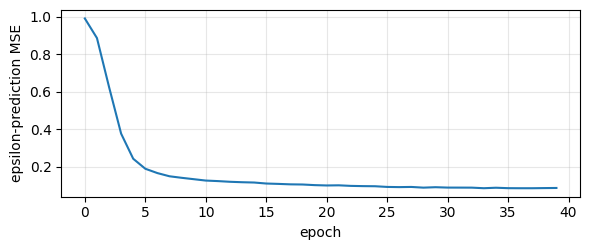

training complete ✓  final loss 0.0870


In [11]:
#@title train
EPOCHS      = 40
BATCH_SIZE  = 128
MAX_LR      = 3e-4
EMA_DECAY   = 0.995
LABEL_DROP  = 0.10

xt = torch.tensor(x_train).permute(0, 2, 1)
yt = torch.tensor(y_train)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt, yt),
                                     batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"{len(xt):,} windows | {len(loader)} batches/epoch | {EPOCHS*len(loader)} steps")

ema = copy.deepcopy(model).eval().requires_grad_(False)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=MAX_LR, total_steps=EPOCHS*len(loader), pct_start=0.1)

hist = []
pbar = tqdm(range(EPOCHS), desc="training")
for epoch in pbar:
    model.train(); running, seen = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        drop = torch.rand(len(yb), device=device) < LABEL_DROP
        yb = torch.where(drop, torch.full_like(yb, N_CLASSES), yb)      # null token
        t = torch.randint(0, T_STEPS, (len(xb),), device=device)
        e = torch.randn_like(xb)
        loss = F.mse_loss(model(q_sample(xb, t, e), t, yb), e)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        with torch.no_grad():
            for p, q in zip(ema.parameters(), model.parameters()):
                p.mul_(EMA_DECAY).add_(q, alpha=1-EMA_DECAY)
        running += loss.item()*len(xb); seen += len(xb)
    hist.append(running/seen); pbar.set_postfix(loss=f"{hist[-1]:.4f}")

plt.figure(figsize=(6,2.6)); plt.plot(hist, lw=1.5)
plt.xlabel("epoch"); plt.ylabel("epsilon-prediction MSE"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"training complete ✓  final loss {hist[-1]:.4f}")

In [12]:
#@title guided sampler
@torch.no_grad()
def sample(n, cls, guidance=1.0, clip=5.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, CHANNELS, WINDOW, generator=g).to(device)
    y    = torch.full((n,), cls,       device=device, dtype=torch.long)
    null = torch.full((n,), N_CLASSES, device=device, dtype=torch.long)
    for i in reversed(range(T_STEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = ema(x, t, y)
        if guidance != 1.0:
            eps_u = ema(x, t, null)
            eps = eps_u + guidance * (eps - eps_u)             # classifier-free guidance
        x0 = ((x - sqrt_1mab[i]*eps) / sqrt_abar[i]).clamp(-clip, clip)
        mean = coef_x0[i]*x0 + coef_xt[i]*x
        x = mean + post_var[i].sqrt()*torch.randn(x.shape, generator=g).to(device) if i > 0 else mean
    return x

N_PER_CLASS = 48
bank = {}
for w in [1.0, 2.0]:
    bank[w] = [sample(N_PER_CLASS, c, guidance=w, seed=10+c).cpu().numpy() for c in range(N_CLASSES)]
    print(f"sampled guidance w={w}")

sampled guidance w=1.0


sampled guidance w=2.0


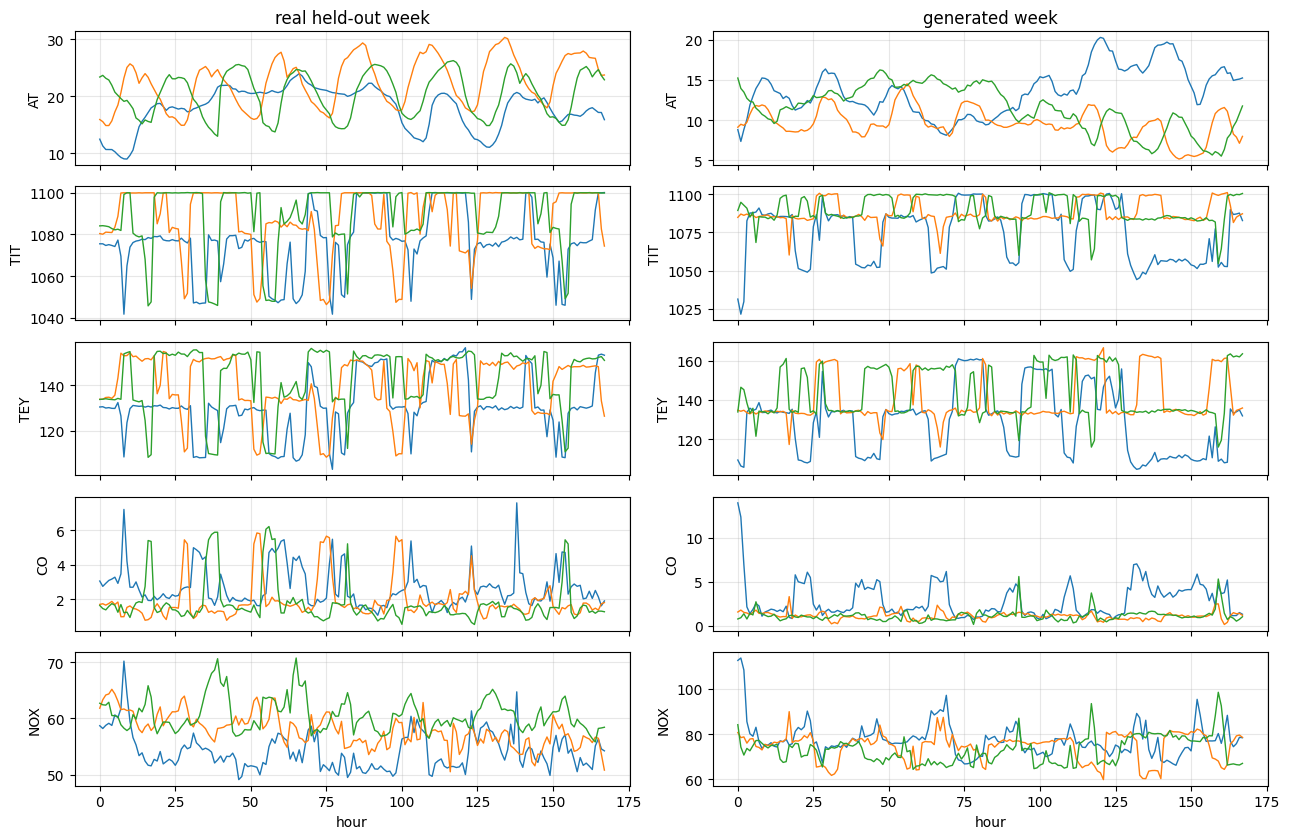

In [13]:
#@title what does a generated week look like?
gen  = to_physical(np.concatenate(bank[1.0]))
real = to_physical(x_test[np.random.RandomState(0).choice(len(x_test), len(gen), replace=False)].transpose(0,2,1))
show = ["AT","TIT","TEY","CO","NOX"]
fig, axes = plt.subplots(len(show), 2, figsize=(13, 1.7*len(show)), sharex=True)
for r, tag in enumerate(show):
    k = TAGS.index(tag)
    for c, (src, ttl) in enumerate([(real, "real held-out week"), (gen, "generated week")]):
        for j in range(3): axes[r, c].plot(src[j, :, k], lw=1)
        axes[r, c].set_ylabel(tag); axes[r, c].grid(alpha=0.3)
        if r == 0: axes[r, c].set_title(ttl)
axes[-1,0].set_xlabel("hour"); axes[-1,1].set_xlabel("hour")
plt.tight_layout(); plt.show()

## The physics scorecard

We do not ask whether the samples *look* right — we ask whether they obey the machine. Every
reference band is measured from the real data.

One row is there to keep you honest: **`real + 0.10 sigma noise`** is genuine training data with a
little white noise added. It shows what these checks read when the only thing wrong is a small
amount of imprecision — the fairest yardstick for a model.

In [14]:
#@title scorecard
def scorecard(P):
    # P: (N, L, C) in engineering units
    g = lambda c: P[:, :, TAGS.index(c)]
    return {
        "corr(TEY,CDP)":    np.corrcoef(g("TEY").ravel(), g("CDP").ravel())[0,1],
        "corr(CO,TIT)":     np.corrcoef(g("CO").ravel(),  g("TIT").ravel())[0,1],
        "CO<0 %":           100*(g("CO") < 0).mean(),
        "worst CO":         g("CO").min(),
        "TIT>1101 %":       100*(g("TIT") > 1101).mean(),
        "TIT at ceiling %": 100*(g("TIT") >= 1099).mean(),
        "TAT at setpoint %":100*((g("TAT") >= 549) & (g("TAT") <= 551)).mean(),
        "AT lag-1 acf":     float(np.mean([np.corrcoef(w[:-1], w[1:])[0,1] for w in g("AT")])),
    }

real_tr = to_physical(x_train[np.random.RandomState(1).choice(len(x_train), len(gen), replace=False)].transpose(0,2,1))

# reference: real training data plus a little white noise
zz = x_train[np.random.RandomState(1).choice(len(x_train), len(gen), replace=False)].transpose(0,2,1)
noisy = to_physical(zz + np.random.RandomState(2).randn(*zz.shape).astype(np.float32)*0.10)

# a strong Gaussian baseline: per-hour multivariate normal fitted on the training windows.
# By construction it reproduces every cross-channel correlation almost exactly.
flat = x_train.reshape(-1, CHANNELS)
gauss_z = np.random.RandomState(0).multivariate_normal(flat.mean(0), np.cov(flat.T),
                                                       size=len(gen)*WINDOW).reshape(len(gen), WINDOW, CHANNELS)
gauss = gauss_z.copy(); gauss = gauss * sd + mu
gauss[..., CO_IDX] = np.expm1(gauss[..., CO_IDX])

report = pd.DataFrame({
    "REAL train":              scorecard(real_tr),
    "REAL held-out":           scorecard(real),
    "real + 0.10 sigma noise": scorecard(noisy),
    "diffusion w=1":           scorecard(to_physical(np.concatenate(bank[1.0]))),
    "diffusion w=2":           scorecard(to_physical(np.concatenate(bank[2.0]))),
    "Gaussian":                scorecard(gauss),
}).T
print(report.round(3).to_string())

                         corr(TEY,CDP)  corr(CO,TIT)  CO<0 %  worst CO  TIT>1101 %  TIT at ceiling %  TAT at setpoint %  AT lag-1 acf
REAL train                       0.988        -0.723   0.000     0.000       0.000            21.863             69.916         0.964
REAL held-out                    0.987        -0.658   0.000     0.002       0.000            25.190             67.167         0.959
real + 0.10 sigma noise          0.978        -0.717   0.153    -0.067       6.056            15.910             55.717         0.909
diffusion w=1                    0.989        -0.844   0.058    -0.391       0.587            16.696             72.768         0.960
diffusion w=2                    0.987        -0.842   0.128    -0.294       0.864            17.374             71.458         0.960
Gaussian                         0.989        -0.760   2.170    -0.576      14.501            17.407              8.809        -0.003


**The Gaussian passes the correlation test and is still nonsense.** It reproduces `corr(TEY,CDP)`
at 0.989 against the real 0.988 — it was fitted to the covariance, so of course it does. And yet
its lag-1 autocorrelation is **−0.003**: it draws every hour independently, so there is no such
thing as a "week" in its output. The exhaust setpoint mode collapses from 70% of hours to **8.8%**
and it spends **14.5%** of hours above a firing temperature the real unit never once crosses.

That is the argument for generative modelling in one row of a table: **matching the covariance is
not the same as learning the process.**

**The diffusion model holds the controller signatures.** Autocorrelation 0.960 against a real
0.964, and the exhaust setpoint mode at 73% against a real 70% — a near point mass 0.26σ wide,
the hardest thing here to reproduce. Worst CO in 144 generated weeks is **−0.39 mg/m³**, inside
analyser noise.

The **`real + 0.10 sigma noise`** row is genuine data with a little imprecision added, and it
fails these checks *harder than the model does* on every column. The `TIT>1101` threshold sits
only **1.06σ above the mean**, so any small error crosses it. When your model is cleaner than real
data plus 10% noise, what is left is measuring the resolution of the test, not the physics.

**Where it is still wrong.** It under-reproduces the limiter — 16.7% of hours near the ceiling
against a real 21.9% — and over-couples CO to firing temperature (−0.84 against −0.72). It knows
the limiter and the coupling exist; it has not learned exactly how hard.

In [15]:
#@title does the conditioning actually control anything?
rows = {}
for w in [1.0, 2.0]:
    rows[f"generated w={w}"] = {CLASS_NAMES[c]: to_physical(bank[w][c])[:, :, AT].mean() for c in range(N_CLASSES)}
rows["real (training)"] = {CLASS_NAMES[c]: (x_train[y_train == c][:, :, AT].mean()*sd[AT] + mu[AT]) for c in range(N_CLASSES)}
tab = pd.DataFrame(rows).T
tab["hot - cold"] = tab["hot"] - tab["cold"]
print("mean ambient temperature of generated weeks, by requested class (degC)\n")
print(tab.round(2).to_string())

mean ambient temperature of generated weeks, by requested class (degC)

                  cold   mild    hot  hot - cold
generated w=1.0  11.28  18.53  24.88       13.59
generated w=2.0   8.41  18.15  26.38       17.96
real (training)  10.25  18.08  25.40       15.15


Guidance behaves the way the theory says. At `w = 1` the model separates the classes but
**understates** the real spread — 13.6 °C cold-to-hot against 15.2 °C in the data. At `w = 2` it
**overshoots** to 18.0 °C. Guidance buys obedience to the label and pays in sample diversity;
neither setting is simply better.

## Doing the job: filling the holes in the historian

Everything so far was about whether the model is any good. This section uses it.

To fill a hole you condition on the hours you *do* have and generate only the hours you do not —
RePaint-style inpainting. At every reverse step the observed region is overwritten with the true
values noised to that step, so the model is always denoising a week whose known part is correct.

Scored against withheld truth on 2014–15, years the model never saw.

In [16]:
#@title inpainting sampler (RePaint-style, conditioned)
@torch.no_grad()
def inpaint(known, mask, cls, guidance=1.0, resample=2, clip=5.0, seed=0):
    # known: (N,C,L) model space. mask: 1 = observed, 0 = to be filled
    n = len(known)
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, CHANNELS, WINDOW, generator=g).to(device)
    y    = cls.to(device)
    null = torch.full((n,), N_CLASSES, device=device, dtype=torch.long)
    for i in reversed(range(T_STEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        for r in range(resample):
            e = torch.randn(known.shape, generator=g).to(device)
            x = mask * (sqrt_abar[i] * known + sqrt_1mab[i] * e) + (1 - mask) * x   # pin observed hours
            eps = ema(x, t, y)
            if guidance != 1.0:
                eps_u = ema(x, t, null); eps = eps_u + guidance * (eps - eps_u)
            x0   = ((x - sqrt_1mab[i] * eps) / sqrt_abar[i]).clamp(-clip, clip)
            mean = coef_x0[i] * x0 + coef_xt[i] * x
            x = mean + post_var[i].sqrt() * torch.randn(x.shape, generator=g).to(device) if i > 0 else mean
            if r < resample - 1 and i > 0:                                          # RePaint jump-back
                z = torch.randn(x.shape, generator=g).to(device)
                x = (1 - betas[i]).sqrt() * x + betas[i].sqrt() * z
    return mask * known + (1 - mask) * x

N_FILL = 32
sel    = np.random.RandomState(0).choice(len(x_test), N_FILL, replace=False)
truth  = torch.tensor(x_test[sel]).permute(0, 2, 1).to(device)
truth_cls = torch.tensor(y_test[sel])
print(f"filling gaps in {N_FILL} held-out weeks from 2014-15")

filling gaps in 32 held-out weeks from 2014-15


### How long does a gap have to be before interpolation stops working?

This is the question worth answering, and the first version of this lab got it wrong by only ever
testing a six-hour gap. Six hours is the *best possible case for a straight line* — these signals
barely move in six hours, so of course interpolation wins.

So sweep the gap length. Every tag goes missing for **6, 12, 24, 48 and 72 consecutive hours** in
the middle of the week, and we score four fills against the truth:

| Method | What it assumes |
|---|---|
| **linear** | the signal goes straight from the last good reading to the first good one |
| **hold-last** | nothing changed while you were blind |
| **prev-day** | the unit does the same thing today it did yesterday at this hour |
| **diffusion** | a plausible week, consistent with the hours you can see |

In [17]:
#@title the crossover - gap length vs fill error
GAPS, N_DRAWS = [6, 12, 24, 48, 72], 5
rows, fills = [], {}
for L in tqdm(GAPS, desc="gap lengths"):
    G0 = (WINDOW - L) // 2
    G1 = G0 + L
    mask = torch.ones_like(truth); mask[:, :, G0:G1] = 0

    # a generative model gives you a SAMPLE, not an estimate. Draw several and take the median.
    draws = torch.stack([inpaint(truth, mask, truth_cls, seed=100+s) for s in range(N_DRAWS)])
    one, med = draws[0], draws.median(0).values

    lin  = truth.clone()
    ramp = torch.linspace(0, 1, L + 2, device=device)[1:-1]
    a, b = truth[:, :, G0-1], truth[:, :, G1]
    lin[:, :, G0:G1] = a[:, :, None] + (b - a)[:, :, None] * ramp[None, None, :]

    hold = truth.clone(); hold[:, :, G0:G1] = truth[:, :, G0-1][:, :, None]

    # same clock hour on the most recent OBSERVED day - never sources from inside the gap
    src = torch.arange(G0, G1, device=device)
    src = src - 24 * ((src - G0) // 24 + 1)
    assert int(src.min()) >= 0 and int(src.max()) < G0, "prev-day baseline peeked inside the gap"
    prof = truth.clone(); prof[:, :, G0:G1] = truth[:, :, src]

    hole = (mask == 0)
    row = {"gap hours": L}
    for nm, p in [("linear", lin), ("hold-last", hold), ("prev-day", prof),
                  ("diffusion, 1 draw", one), (f"diffusion, median of {N_DRAWS}", med)]:
        row[nm] = float((p - truth).abs()[hole].mean())
    rows.append(row)
    fills[L] = (med, lin, draws, G0, G1)

cross = pd.DataFrame(rows).set_index("gap hours")
MED = f"diffusion, median of {N_DRAWS}"
print("mean absolute error over the missing hours, all 11 tags, in sigma units\n")
print(cross.round(3).to_string())
print("\nbest method by gap length:")
print(cross.idxmin(axis=1).to_string())

gap lengths:   0%|          | 0/5 [00:00<?, ?it/s]

mean absolute error over the missing hours, all 11 tags, in sigma units

           linear  hold-last  prev-day  diffusion, 1 draw  diffusion, median of 5
gap hours                                                                        
6           0.344      0.460     0.492              0.416                   0.397
12          0.400      0.568     0.516              0.455                   0.452
24          0.559      0.633     0.532              0.557                   0.488
48          0.571      0.628     0.611              0.635                   0.523
72          0.620      0.767     0.690              0.700                   0.573

best method by gap length:
gap hours
6                     linear
12                    linear
24    diffusion, median of 5
48    diffusion, median of 5
72    diffusion, median of 5


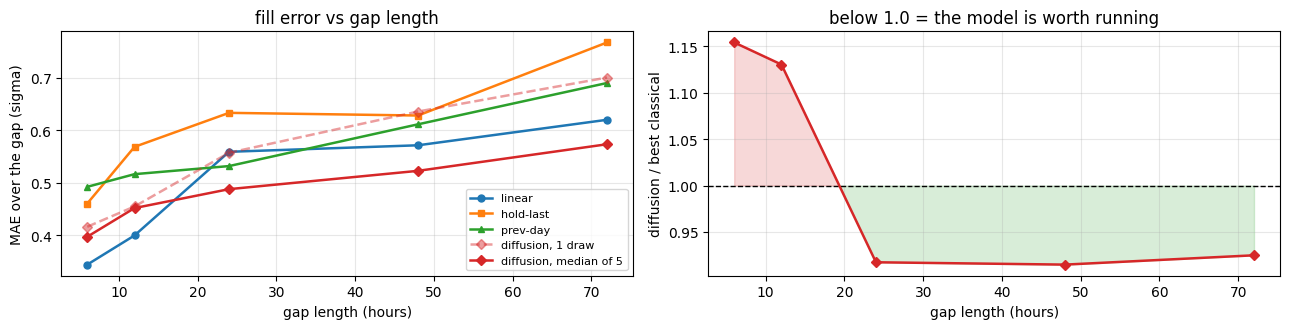

crossover: the model overtakes every classical method somewhere between 12 and 24 hours


In [18]:
#@title the crossover, drawn
CLASSICAL = ["linear", "hold-last", "prev-day"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for nm, style in [("linear","-o"), ("hold-last","-s"), ("prev-day","-^"),
                  ("diffusion, 1 draw","--D"), (MED,"-D")]:
    ax[0].plot(cross.index, cross[nm], style, lw=1.8, ms=5, label=nm,
               color="tab:red" if "diffusion" in nm else None,
               alpha=0.45 if nm == "diffusion, 1 draw" else 1.0)
ax[0].set_xlabel("gap length (hours)"); ax[0].set_ylabel("MAE over the gap (sigma)")
ax[0].set_title("fill error vs gap length"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ratio = cross[MED] / cross[CLASSICAL].min(axis=1)
ax[1].axhline(1.0, color="k", lw=1, ls="--")
ax[1].plot(cross.index, ratio, "-D", lw=1.8, ms=5, color="tab:red")
ax[1].fill_between(cross.index, 1.0, ratio, where=(ratio<=1), alpha=0.18, color="tab:green", interpolate=True)
ax[1].fill_between(cross.index, 1.0, ratio, where=(ratio>1),  alpha=0.18, color="tab:red",   interpolate=True)
ax[1].set_xlabel("gap length (hours)"); ax[1].set_ylabel("diffusion / best classical")
ax[1].set_title("below 1.0 = the model is worth running"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

below = ratio[ratio < 1.0]
if len(below) and len(ratio[ratio >= 1.0]):
    print(f"crossover: the model overtakes every classical method somewhere between "
          f"{int(ratio[ratio>=1.0].index.max())} and {int(below.index.min())} hours")

**There is your answer, and it is a number you can put on a work instruction.**

**Under a day, interpolate.** At 6 and 12 hours a straight line beats everything else on the
sheet. These signals barely move in that time.

**Past a day, run the model.** At 24 hours it takes over — 0.488σ against the best classical
0.532σ — and holds the lead at 48 hours (0.523 vs 0.571) and 72 (0.573 vs 0.620). **The crossover
is between 12 and 24 hours on this unit.**

Look at *how* they degrade. From a 6-hour gap to a 3-day gap, linear interpolation's error grows
**80%**; the model's grows **44%**. A straight line has nothing to say about the middle of a long
hole, and the longer the hole the more obvious that is.

**Now compare the two diffusion columns.** A single draw loses at every gap length — 0.557 at 24
hours, behind prev-day's 0.532. The median of five wins at three of the five. Same model, same
weights, same gaps; the only difference is how the prediction was formed.

That is not a trick, it is the correct way to score a generative model. Mean absolute error
rewards whatever is closest to the *conditional mean*, and a single sample is not trying to be the
mean — it is one plausible week out of many. Interpolation is effectively a conditional-mean
estimator, so comparing it against one draw compares two different things.

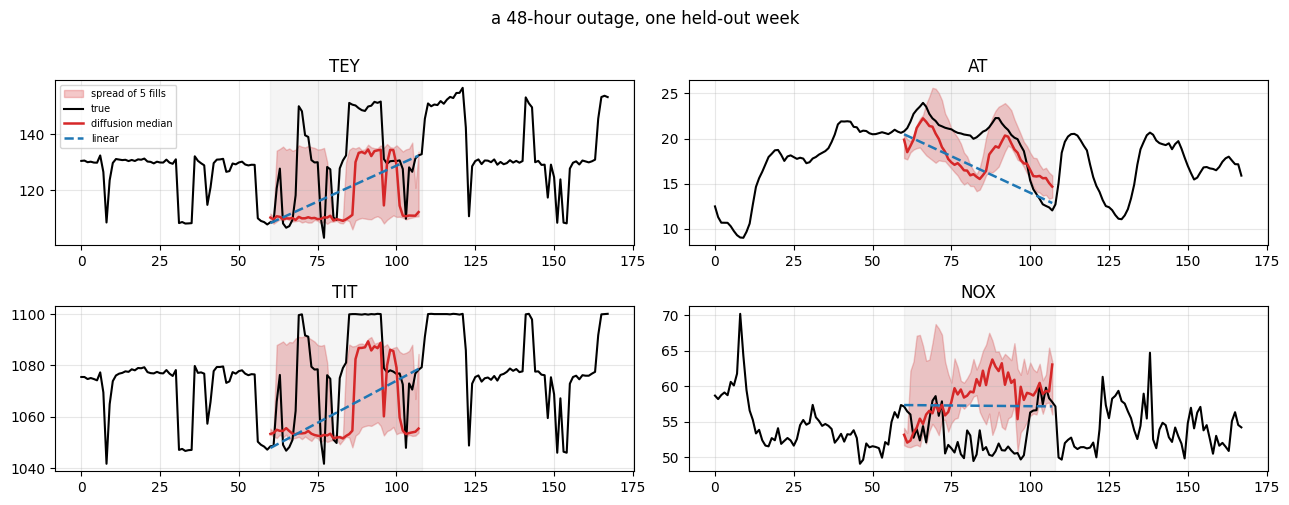

In [19]:
#@title what a long fill actually looks like - with an uncertainty band
LSHOW = 48 if 48 in fills else max(fills)
med, lin, draws, G0, G1 = fills[LSHOW]
fig, axes = plt.subplots(2, 2, figsize=(13, 5))
for j, ax in enumerate(axes.ravel()):
    tag = ["TEY","AT","TIT","NOX"][j]; kk = TAGS.index(tag)
    unphys = lambda z: z.cpu().numpy()*sd[kk] + mu[kk]
    band = draws[:, 0, kk, G0:G1]
    ax.fill_between(np.arange(G0, G1), unphys(band.min(0).values), unphys(band.max(0).values),
                    alpha=0.25, color="tab:red", label="spread of 5 fills")
    ax.plot(np.arange(WINDOW), unphys(truth[0, kk]), lw=1.5, color="k", label="true")
    ax.plot(np.arange(G0, G1), unphys(med[0, kk, G0:G1]), lw=1.8, color="tab:red", label="diffusion median")
    ax.plot(np.arange(G0, G1), unphys(lin[0, kk, G0:G1]), lw=1.8, ls="--", color="tab:blue", label="linear")
    ax.axvspan(G0, G1, alpha=0.08, color="grey"); ax.set_title(tag); ax.grid(alpha=0.3)
axes[0,0].legend(fontsize=7)
plt.suptitle(f"a {LSHOW}-hour outage, one held-out week", y=1.00)
plt.tight_layout(); plt.show()

In [20]:
#@title is a low error the same thing as a realistic fill?
LCHK = 48 if 48 in fills else max(fills)
medf, lin, draws, G0, G1 = fills[LCHK]
hold = truth.clone(); hold[:, :, G0:G1] = truth[:, :, G0-1][:, :, None]
kT = TAGS.index("TIT")

rows = {}
for nm, p in [("truth", truth), ("diffusion, 1 draw", draws[0]), (f"diffusion, median of {N_DRAWS}", medf),
              ("linear", lin), ("hold-last", hold)]:
    seg = p[:, :, G0:G1]
    rows[nm] = {
        "hour-to-hour movement (sigma)": float((seg[:, :, 1:] - seg[:, :, :-1]).abs().mean()),
        "spread within the gap (sigma)": float(seg.std(dim=2).mean()),
        "TIT hours at the limiter %":    float(100*((seg[:, kT]*float(sd[kT]) + float(mu[kT])) >= 1099).float().mean()),
    }
print(f"what the fill LOOKS like over a {LCHK}-hour gap (truth is the target, not zero)\n")
print(pd.DataFrame(rows).T.round(3).to_string())

what the fill LOOKS like over a 48-hour gap (truth is the target, not zero)

                        hour-to-hour movement (sigma)  spread within the gap (sigma)  TIT hours at the limiter %
truth                                           0.218                          0.610                      22.266
diffusion, 1 draw                               0.201                          0.593                      11.719
diffusion, median of 5                          0.167                          0.470                       4.688
linear                                          0.013                          0.181                      16.146
hold-last                                       0.000                          0.000                      21.875


This is the other half of the story, and the error table cannot show it.

**Interpolation buys its low error by flattening the signal.** The real unit moves 0.218σ hour to
hour; the straight line moves **0.013σ**, one seventeenth as much, and carries 0.181σ of spread
against a real 0.610σ. Hold-last moves exactly zero. These fills score well precisely because they
refuse to commit to any structure — and structure is what you are missing.

**A single diffusion draw is the only fill with the right texture:** movement 0.201σ against the
real 0.218σ, spread 0.593σ against 0.610σ. In the figure above it is the trace that looks like a
turbine. The median of five is visibly smoother (0.167σ, 0.470σ) — averaging draws is exactly what
makes it a better *estimate* and a worse *realisation*.

**And the column that does not flatter the model.** The real week spends 22.3% of its gap hours at
the temperature limiter. Every fill undercounts: linear 16.1%, a single draw 11.7%, the median only
4.7%. Hold-last scores best at 21.9% purely because the hour before the gap was already at the
limiter and it never moves — an accident, not skill. **Do not count exceedances inside a filled
gap by any of these methods.** Flag those hours as missing.

| If you need... | Use |
|---|---|
| the best estimate of each missing hour | **interpolation under a day, the median fill over a day** |
| a realistic week — simulation, operator training, augmentation | **a single draw** |
| an uncertainty band | **the model** — fill repeatedly and report the spread |
| a limiter or exceedance count inside the gap | **none of them** |

### Scenario 2: the NOx analyser is down for the whole week

A different shape of problem. Nothing is missing in *time* — one **channel** is dead for all 168
hours, and the other ten are healthy. There is nothing to interpolate between, so the question is
whether the unit's other tags tell you what NOx was doing.

The baseline here is the one an engineer would actually build: **an ordinary least-squares fit of
NOx on the other ten tags**, estimated from the same 22,000 training hours.

In [21]:
#@title scenario 2 - reconstructing a dead analyser
k = TAGS.index("NOX")
maskB = torch.ones_like(truth); maskB[:, k, :] = 0
filledB = inpaint(truth, maskB, truth_cls, seed=2)

others = [j for j in range(CHANNELS) if j != k]
flat = x_train.reshape(-1, CHANNELS)
A    = np.c_[flat[:, others], np.ones(len(flat))]
coef = np.linalg.lstsq(A, flat[:, k], rcond=None)[0]
G    = truth.cpu().numpy()
ols  = torch.from_numpy((np.einsum("bcl,c->bl", G[:, others, :], coef[:-1]) + coef[-1]).astype(np.float32)).to(device)

rows = {}
for name, pred in [("diffusion", filledB[:, k, :]),
                   ("train mean", torch.zeros_like(truth[:, k, :])),
                   ("cross-channel OLS", ols)]:
    err = pred - truth[:, k, :]
    rows[name] = {"MAE (mg/m3)":       float(err.abs().mean() * sd[k]),
                  "bias (mg/m3)":      float(err.mean() * sd[k]),
                  "MAE after de-bias": float((err - err.mean()).abs().mean() * sd[k])}
print("reconstructing a week of NOx from the ten healthy tags\n")
print(pd.DataFrame(rows).T.round(2).to_string())
print(f"\nreal NOx in these weeks spans {(truth[:,k,:].min()*sd[k]+mu[k]):.1f} to {(truth[:,k,:].max()*sd[k]+mu[k]):.1f} mg/m3")
print(f"the 2013->2014 regime break was {abs(shift['NOX'])*sd[k]:.1f} mg/m3")

reconstructing a week of NOx from the ten healthy tags

                   MAE (mg/m3)  bias (mg/m3)  MAE after de-bias
diffusion                10.41          9.05               5.60
train mean               12.57          9.53               7.83
cross-channel OLS         8.61          6.02               6.58

real NOx in these weeks spans 35.7 to 119.7 mg/m3
the 2013->2014 regime break was 8.8 mg/m3


**Read all three columns.** On raw error the cross-channel fit wins: 8.61 mg/m³ against the
diffusion model's 10.41. Stop there and the answer is "regress dead analysers".

But split the error into **bias** (wrong level) and **scatter** (wrong shape) and it inverts. The
model's bias is **9.05 mg/m³**, and the NOx regime break from the second diagnostic cell was
**8.8 mg/m³**. Essentially *all* of its disadvantage is that it faithfully reproduces the unit as
it ran before the 2014 retrofit, because that is the only unit it was shown. Remove the offset and
it reconstructs the shape of the week **better than OLS** — 5.60 mg/m³ against 6.58.

> **Recalibrate the level against any post-retrofit reference you have, and the generative fill is
> the most accurate reconstruction available.** With no reference at all, use OLS — a model that is
> confidently 9 mg/m³ high is worse than a cruder one that is not.

This generalises well past diffusion models: **when a model trained on history underperforms on
new data, split the error into bias and scatter before concluding the model is bad.** Pure bias is
a recalibration job; pure scatter means it does not know the process. Different problems, and the
raw error cannot tell them apart.

## Where this leaves you

You built a generative model of a real gas turbine, checked it against measured physics rather
than by eye, and used it to fill real holes in a real historian — scored against withheld truth on
years the model never saw. Two rules came out of it that you can use on shift:

> **Gaps under a day: interpolate. Gaps over a day: fill with the median of five draws.**
>
> **A dead analyser: recalibrate the level first, then the generative fill beats regression.**

**The lesson to carry out of the room.** The Gaussian baseline matches every correlation in the
data and is still physically impossible. Second-moment agreement is not process knowledge. When
someone shows you synthetic process data, ask what *physical* constraint they checked — not what
correlation they matched.

**Three traps this lab is built around, all of which caught the first version of it:**

- **Bounded, skewed tags need a transform.** Raw `CO` has skew 4.9 and a floor one sigma below its
  mean; a Gaussian-support model generates negative concentrations from it no matter how well
  trained. `log1p` fixes it structurally rather than with a clamp bolted on afterwards.
- **A generative model gives you a sample, not an estimate.** Scoring one draw on mean error
  compares the wrong things. That single change flips the gap-filling verdict.
- **Check the difficulty axis.** A six-hour hole is the best possible case for a straight line.
  Testing only that is testing nothing.

**Honest limitations.** ~132 independent training weeks, whatever the window count says — a
small-data problem, and why the model needs the full training budget; at half the steps it misses
the limiter and the setpoint badly. Windows are index-contiguous, not time-contiguous, since
13–18% of calendar hours are missing and unlocatable without timestamps. The model generates
pre-2014 NOx. Conditioning is a coarse 3-way ambient bucket.

**Worth trying next.** Condition on load as well as weather and generate a hot-week-at-full-load
case the plant has never run, then read CO and NOx against your permit limit to size the headroom.

**References.** Ho, Jain & Abbeel, *DDPM* (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)
· Ho & Salimans, *Classifier-Free Diffusion Guidance* (2022),
[arXiv:2207.12598](https://arxiv.org/abs/2207.12598) · Lugmayr et al., *RePaint* (2022),
[arXiv:2201.09865](https://arxiv.org/abs/2201.09865) · Kaya, Tüfekci & Uzun (2019); dataset at
[UCI](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set), CC BY 4.0